In [1]:
# NAME : ASAD AHMED
# ROLL NO: 23-AI-14

!pip install mediapipe==0.10.35

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.6 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
import cv2
import numpy as np

def merge_videos(video1_path, video2_path, output_path):
    cap1 = cv2.VideoCapture(video1_path)
    cap2 = cv2.VideoCapture(video2_path)

    fps1 = cap1.get(cv2.CAP_PROP_FPS) or 30
    fps2 = cap2.get(cv2.CAP_PROP_FPS) or 30
    w1, h1 = int(cap1.get(cv2.CAP_PROP_FRAME_WIDTH)),  int(cap1.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w2, h2 = int(cap2.get(cv2.CAP_PROP_FRAME_WIDTH)),  int(cap2.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fps = fps1
    target_height = min(h1, h2, 720)
    new_w1 = int(w1 * (target_height / h1))
    new_w2 = int(w2 * (target_height / h2))
    out_w  = max(new_w1, new_w2)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (out_w, target_height))

    total_v1 = 0
    total_v2 = 0

    while cap1.isOpened():
        ret, frame = cap1.read()
        if not ret: break
        resized = cv2.resize(frame, (new_w1, target_height))
        if new_w1 < out_w:
            pad = np.zeros((target_height, out_w - new_w1, 3), dtype=np.uint8)
            resized = np.hstack([resized, pad])
        out.write(resized)
        total_v1 += 1

    while cap2.isOpened():
        ret, frame = cap2.read()
        if not ret: break
        resized = cv2.resize(frame, (new_w2, target_height))
        if new_w2 < out_w:
            pad = np.zeros((target_height, out_w - new_w2, 3), dtype=np.uint8)
            resized = np.hstack([resized, pad])
        out.write(resized)
        total_v2 += 1

    cap1.release()
    cap2.release()
    out.release()

    print(f" Merged successfully!")
    print(f"   Video 1 (Man running+jumping):          {total_v1} frames")
    print(f"   Video 2 (Man running):   {total_v2} frames")
    print(f"   Saved to: {output_path}")

    return total_v1, total_v2

#  Update paths
VIDEO1_PATH = '/content/jumping_man_video.mp4'
VIDEO2_PATH = '/content/running_man_video.mp4'
MERGED_PATH = '/content/merged_video.mp4'

frames_v1, frames_v2 = merge_videos(VIDEO1_PATH, VIDEO2_PATH, MERGED_PATH)
TRANSITION_FRAME = frames_v1
print(f"\n Running → Walking transition at frame: {TRANSITION_FRAME}")

 Merged successfully!
   Video 1 (Man running+jumping):          367 frames
   Video 2 (Man running):   571 frames
   Saved to: /content/merged_video.mp4

 Running → Walking transition at frame: 367


Processing: 1354x720 @ 30.4 fps
 Total frames:        938
 Pose detected:       820
 No pose detected:    118

 Sample — Man (Running/jumping):


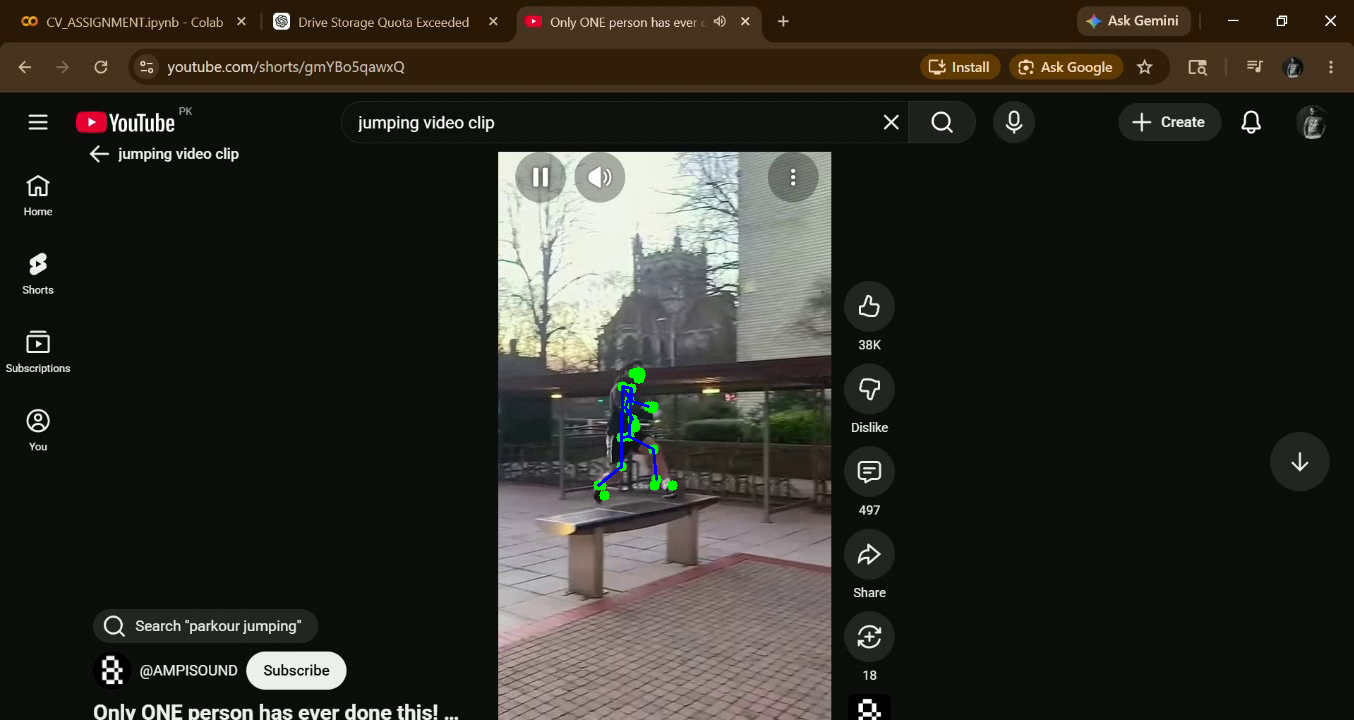


 Sample — Man (Running):


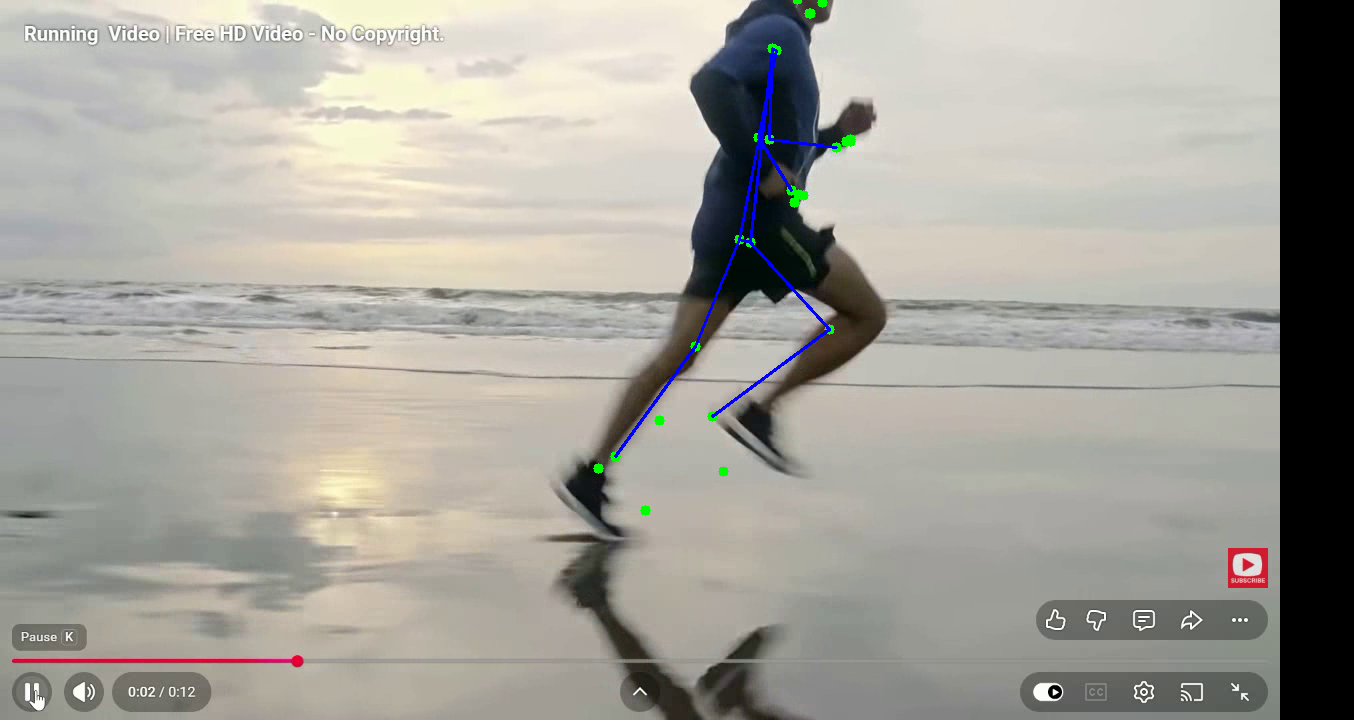

In [3]:
import mediapipe as mp
from collections import deque
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

!wget -q -O pose_landmarker.task -c https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task

BaseOptions        = mp.tasks.BaseOptions
PoseLandmarker     = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode  = mp.tasks.vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='pose_landmarker.task'),
    running_mode=VisionRunningMode.VIDEO
)
landmarker = PoseLandmarker.create_from_options(options)

# Skeleton connections
POSE_CONNECTIONS = [
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (11, 23), (12, 24),
    (23, 24),
    (23, 25), (25, 27),
    (24, 26), (26, 28),
]

def draw_pose_landmarks(frame, landmarks, h, w, activity=None):
    """Draw skeleton with color based on detected activity"""
    color_map = {
        'Running': ((0, 255, 255),   (0, 165, 255)),   # yellow joints, orange bones
        'Walking': ((0, 255, 0),     (255, 255, 0)),    # green joints, cyan bones
        'Sitting': ((255, 0, 255),   (255, 0, 0)),      # magenta joints, blue bones
    }
    joint_color, bone_color = color_map.get(activity, ((0, 255, 0), (255, 0, 0)))

    for lm in landmarks:
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(frame, (cx, cy), 5, joint_color, -1)

    for s, e in POSE_CONNECTIONS:
        if s < len(landmarks) and e < len(landmarks):
            x1, y1 = int(landmarks[s].x * w), int(landmarks[s].y * h)
            x2, y2 = int(landmarks[e].x * w), int(landmarks[e].y * h)
            cv2.line(frame, (x1, y1), (x2, y2), bone_color, 2)

def smooth_keypoints(history, new_points, window=5):
    history.append(new_points)
    if len(history) > window:
        history.popleft()
    return np.mean(history, axis=0)

# Storage
keypoints_history = deque()
all_keypoints     = []
frames            = []
raw_landmarks_list = []  # store raw landmarks for drawing later with labels

cap          = cv2.VideoCapture(MERGED_PATH)
fps          = cap.get(cv2.CAP_PROP_FPS) or 30
frame_width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Processing: {frame_width}x{frame_height} @ {fps:.1f} fps")

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image     = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    timestamp_ms = int(frame_count / fps * 1000)

    detection_result = landmarker.detect_for_video(mp_image, timestamp_ms)
    annotated_frame  = np.copy(frame)

    if detection_result.pose_landmarks and len(detection_result.pose_landmarks) > 0:
        landmark_list   = detection_result.pose_landmarks[0]
        keypoints_array = np.array([[lm.x, lm.y, lm.z] for lm in landmark_list])
        smoothed        = smooth_keypoints(keypoints_history, keypoints_array)
        all_keypoints.append(smoothed)
        raw_landmarks_list.append(landmark_list)

        # Draw skeleton (no activity label yet — added in Task 3)
        draw_pose_landmarks(annotated_frame, landmark_list, frame_height, frame_width)
    else:
        all_keypoints.append(None)
        raw_landmarks_list.append(None)

    frames.append(annotated_frame)
    frame_count += 1

cap.release()
landmarker.close()

print(f" Total frames:        {len(frames)}")
print(f" Pose detected:       {sum(1 for k in all_keypoints if k is not None)}")
print(f" No pose detected:    {sum(1 for k in all_keypoints if k is None)}")

# Show samples
print("\n Sample — Man (Running/jumping):")
cv2_imshow(frames[frames_v1 // 2])

print(f"\n Sample — Man (Running):")
cv2_imshow(frames[TRANSITION_FRAME + frames_v2 // 2])

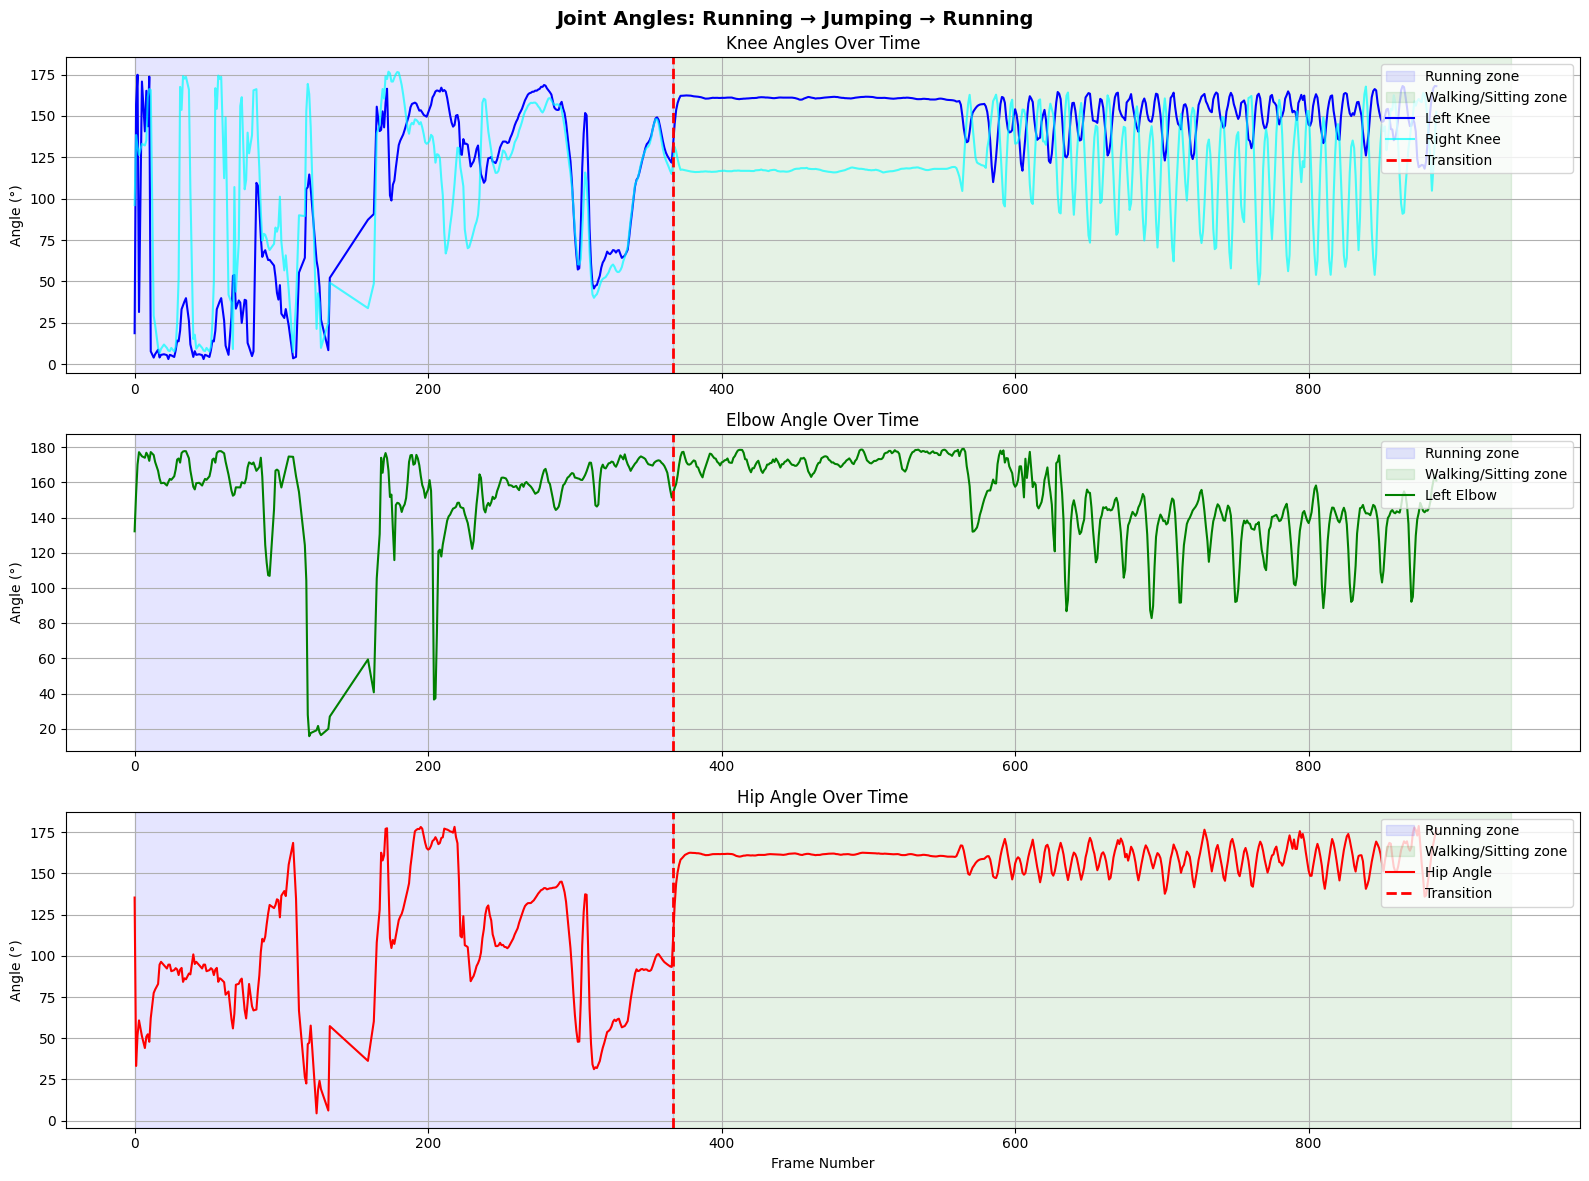


 Average Angles by Video Section:
Angle                Man (Running+Jumping) Man (Running)
-------------------------------------------------------
Knee Left            100.2                153.5
Knee Right           107.5                120.3
Elbow                153.0                152.0
Hip                  104.5                159.9


In [10]:
# TASK 2: Joint Angle Computation

LANDMARKS = {
    'left_shoulder': 11,  'right_shoulder': 12,
    'left_elbow':    13,  'right_elbow':    14,
    'left_wrist':    15,  'right_wrist':    16,
    'left_hip':      23,  'right_hip':      24,
    'left_knee':     25,  'right_knee':     26,
    'left_ankle':    27,  'right_ankle':    28
}

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc  = a - b, c - b
    cosine  = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

knee_angles       = []
knee_right_angles = []
elbow_angles      = []
hip_angles        = []

for kp in all_keypoints:
    if kp is None:
        knee_angles.append(None)
        knee_right_angles.append(None)
        elbow_angles.append(None)
        hip_angles.append(None)
        continue

    knee_L = calculate_angle(
        kp[LANDMARKS['left_hip']][:2],
        kp[LANDMARKS['left_knee']][:2],
        kp[LANDMARKS['left_ankle']][:2]
    )
    knee_R = calculate_angle(
        kp[LANDMARKS['right_hip']][:2],
        kp[LANDMARKS['right_knee']][:2],
        kp[LANDMARKS['right_ankle']][:2]
    )
    elbow = calculate_angle(
        kp[LANDMARKS['left_shoulder']][:2],
        kp[LANDMARKS['left_elbow']][:2],
        kp[LANDMARKS['left_wrist']][:2]
    )
    hip = calculate_angle(
        kp[LANDMARKS['left_shoulder']][:2],
        kp[LANDMARKS['left_hip']][:2],
        kp[LANDMARKS['left_knee']][:2]
    )

    knee_angles.append(knee_L)
    knee_right_angles.append(knee_R)
    elbow_angles.append(elbow)
    hip_angles.append(hip)

# Filter valid
valid_idx    = [i for i, k in enumerate(knee_angles) if k is not None]
knee_valid   = [knee_angles[i]       for i in valid_idx]
knee_R_valid = [knee_right_angles[i] for i in valid_idx]
elbow_valid  = [elbow_angles[i]      for i in valid_idx]
hip_valid    = [hip_angles[i]        for i in valid_idx]

# ── Plot ──
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Shade regions by activity
def shade_region(ax, start, end, color, label):
    ax.axvspan(start, end, alpha=0.1, color=color, label=label)

for ax in axes:
    shade_region(ax, 0,                TRANSITION_FRAME,              'blue',   'Running zone')
    shade_region(ax, TRANSITION_FRAME, TRANSITION_FRAME + frames_v2,  'green',  'Walking/Sitting zone')

axes[0].plot(valid_idx, knee_valid,   color='blue', label='Left Knee',  linewidth=1.5)
axes[0].plot(valid_idx, knee_R_valid, color='cyan', label='Right Knee', linewidth=1.5, alpha=0.7)
axes[0].axvline(x=TRANSITION_FRAME, color='red', linestyle='--', linewidth=2, label='Transition')
axes[0].set_ylabel('Angle (°)')
axes[0].set_title('Knee Angles Over Time')
axes[0].legend(loc='upper right')
axes[0].grid(True)

axes[1].plot(valid_idx, elbow_valid, color='green', label='Left Elbow', linewidth=1.5)
axes[1].axvline(x=TRANSITION_FRAME, color='red', linestyle='--', linewidth=2)
axes[1].set_ylabel('Angle (°)')
axes[1].set_title('Elbow Angle Over Time')
axes[1].legend(loc='upper right')
axes[1].grid(True)

axes[2].plot(valid_idx, hip_valid, color='red', label='Hip Angle', linewidth=1.5)
axes[2].axvline(x=TRANSITION_FRAME, color='red', linestyle='--', linewidth=2, label='Transition')
axes[2].set_xlabel('Frame Number')
axes[2].set_ylabel('Angle (°)')
axes[2].set_title('Hip Angle Over Time')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.suptitle('Joint Angles: Running → Jumping → Running', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('joint_angles.png', dpi=150)
plt.show()

# Print average angles per zone
bolt_idx    = [i for i in valid_idx if i < TRANSITION_FRAME]
man_idx     = [i for i in valid_idx if i >= TRANSITION_FRAME]

print("\n Average Angles by Video Section:")
print(f"{'Angle':<20} {'Man (Running+Jumping)':<20} {'Man (Running)'}")
print("-" * 55)
for name, angles in [('Knee Left', knee_angles), ('Knee Right', knee_right_angles),
                      ('Elbow', elbow_angles), ('Hip', hip_angles)]:
    b_avg = np.mean([angles[i] for i in bolt_idx if angles[i] is not None])
    m_avg = np.mean([angles[i] for i in man_idx  if angles[i] is not None])
    print(f"{name:<20} {b_avg:<20.1f} {m_avg:.1f}")

 Overall Accuracy: 11.72%
   Valid frames:     717/938

 Per-Activity Accuracy:
   Running     : 9.2%  (19/207 frames)
   Walking     : 19.3%  (65/337 frames)
   Sitting     : 0.0%  (0/173 frames)


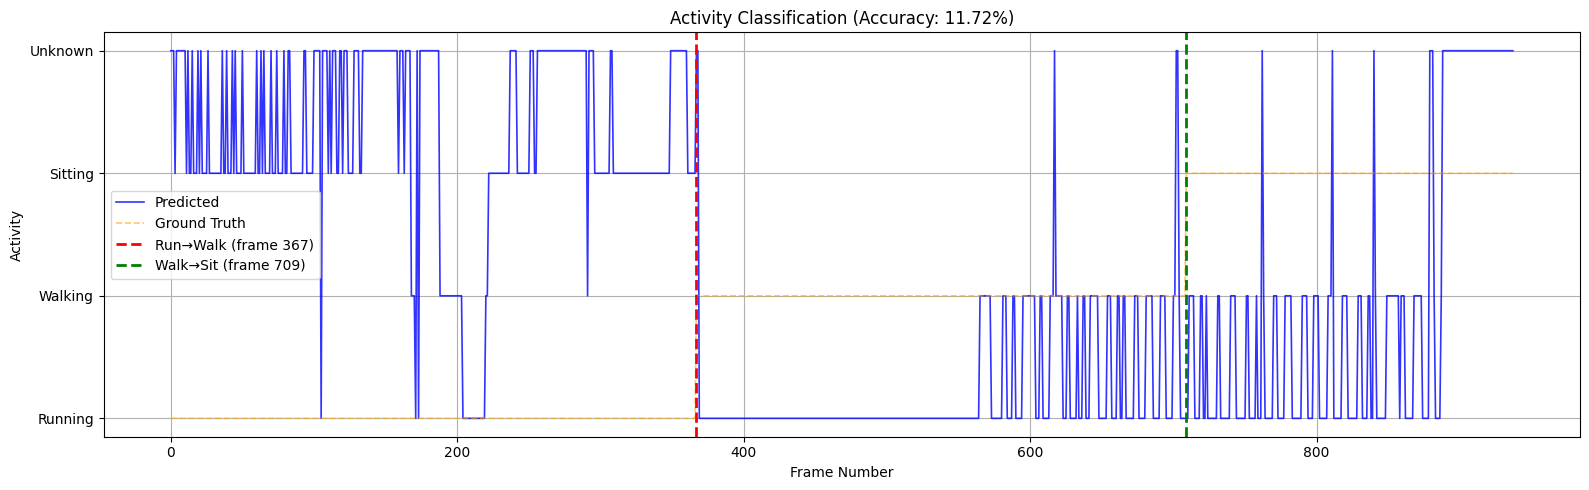


 Sample Per-Frame Report (5 from each activity):
Frame    Knee_L°    Knee_R°    Hip°       Predicted    GT           ✓/✗
------------------------------------------------------------------------
0        18.7       96.1       135.4      Unknown      Running      No
1        156.9      138.5      33.1       Unknown      Running      No
2        174.9      131.3      51.9       Unknown      Running      No
3        31.5       126.4      60.8       Sitting      Running      No
4        N/A        N/A        N/A        Unknown      Running      No


In [6]:
# TASK 3: Rule-Based Classification
# Activities: Running, Walking, Sitting

def classify_activity(knee_L, knee_R, hip, elbow):
    """
    Running:  rapid knee alternation, upright, arms pumping
    Walking:  mild knee flex, upright hip, relaxed arms
    Sitting:  both knees AND hip deeply bent (~80–110°)
    """
    if any(v is None for v in [knee_L, knee_R, hip, elbow]):
        return 'Unknown'

    knee_avg  = (knee_L + knee_R) / 2
    knee_diff = abs(knee_L - knee_R)

    # Sitting: both knees bent AND hip bent
    if knee_avg < 115 and hip < 120:
        return 'Sitting'

    # Sitting transition (lowering into chair)
    if knee_avg < 130 and hip < 135:
        return 'Sitting'

    # Running: high knee asymmetry + upright + fast
    if knee_diff > 25 and hip > 140 and knee_avg > 110:
        return 'Running'

    # Walking: mild flex, upright, low asymmetry
    if hip > 145 and 110 < knee_avg < 165 and knee_diff < 35:
        return 'Walking'

    # Running fallback: very upright with some asymmetry
    if hip > 155 and knee_diff > 15:
        return 'Running'

    return 'Unknown'

# Classify all frames
predicted_labels = []
for i in range(len(knee_angles)):
    label = classify_activity(
        knee_angles[i],
        knee_right_angles[i],
        hip_angles[i],
        elbow_angles[i]
    )
    predicted_labels.append(label)

v2_walk_end = TRANSITION_FRAME + int(frames_v2 * 0.6)

ground_truth = []
for i in range(len(predicted_labels)):
    if i < TRANSITION_FRAME:
        ground_truth.append('Running')
    elif i < v2_walk_end:
        ground_truth.append('Walking')
    else:
        ground_truth.append('Sitting')

# Accuracy
correct     = sum(p == g for p, g in zip(predicted_labels, ground_truth) if p != 'Unknown')
valid_count = sum(1 for p in predicted_labels if p != 'Unknown')
accuracy    = (correct / valid_count * 100) if valid_count > 0 else 0

print(f" Overall Accuracy: {accuracy:.2f}%")
print(f"   Valid frames:     {valid_count}/{len(predicted_labels)}")

# Per-activity accuracy
from collections import Counter, defaultdict
per_activity = defaultdict(lambda: [0, 0])  # [correct, total]
for p, g in zip(predicted_labels, ground_truth):
    if p != 'Unknown':
        per_activity[g][1] += 1
        if p == g:
            per_activity[g][0] += 1

print("\n Per-Activity Accuracy:")
for act, (correct_n, total_n) in per_activity.items():
    acc = (correct_n / total_n * 100) if total_n > 0 else 0
    print(f"   {act:<12}: {acc:.1f}%  ({correct_n}/{total_n} frames)")

# Plot
activity_map = {'Running': 0, 'Walking': 1, 'Sitting': 2, 'Unknown': 3}
pred_numeric = [activity_map.get(l, 3) for l in predicted_labels]
gt_numeric   = [activity_map.get(l, 3) for l in ground_truth]

plt.figure(figsize=(16, 5))
plt.plot(pred_numeric, label='Predicted',    alpha=0.8, linewidth=1.2, color='blue')
plt.plot(gt_numeric,   label='Ground Truth', alpha=0.6, linewidth=1.2,
         linestyle='--', color='orange')
plt.axvline(x=TRANSITION_FRAME, color='red',   linestyle='--',
            linewidth=2, label=f'Run→Walk (frame {TRANSITION_FRAME})')
plt.axvline(x=v2_walk_end,      color='green', linestyle='--',
            linewidth=2, label=f'Walk→Sit (frame {v2_walk_end})')
plt.yticks([0, 1, 2, 3], ['Running', 'Walking', 'Sitting', 'Unknown'])
plt.xlabel('Frame Number')
plt.ylabel('Activity')
plt.title(f'Activity Classification (Accuracy: {accuracy:.2f}%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('classification_results.png', dpi=150)
plt.show()

#Per frame table
print("\n Sample Per-Frame Report (5 from each activity):")
print(f"{'Frame':<8} {'Knee_L°':<10} {'Knee_R°':<10} {'Hip°':<10} {'Predicted':<12} {'GT':<12} {'✓/✗'}")
print("-" * 72)

shown = {'Running': 0, 'Jumping': 0, 'Running': 0}
for i in range(len(predicted_labels)):
    gt = ground_truth[i]
    if shown.get(gt, 5) >= 5:
        continue
    shown[gt] = shown.get(gt, 0) + 1

    kL   = f"{knee_angles[i]:.1f}"       if knee_angles[i]       is not None else "N/A"
    kR   = f"{knee_right_angles[i]:.1f}" if knee_right_angles[i] is not None else "N/A"
    h    = f"{hip_angles[i]:.1f}"        if hip_angles[i]        is not None else "N/A"
    flag = "Yes" if predicted_labels[i] == gt else "No"
    print(f"{i:<8} {kL:<10} {kR:<10} {h:<10} {predicted_labels[i]:<12} {gt:<12} {flag}")

In [7]:
cap    = cv2.VideoCapture(MERGED_PATH)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter('output_annotated.mp4', fourcc, fps, (frame_width, frame_height))

activity_colors = {
    'Running': (0, 255, 255),    # Yellow
    'Walking': (0, 255, 0),      # Green
    'Sitting': (255, 0, 255),    # Magenta
    'Unknown': (128, 128, 128)   # Gray
}
for i, frame in enumerate(frames):
    annotated = np.copy(frame)

    if i < len(predicted_labels):
        label = predicted_labels[i]
        color = activity_colors.get(label, (255, 255, 255))

        # Redraw skeleton with activity color
        if i < len(raw_landmarks_list) and raw_landmarks_list[i] is not None:
            draw_pose_landmarks(annotated, raw_landmarks_list[i],
                                frame_height, frame_width, activity=label)

        #show activity label
        cv2.putText(annotated, f'Activity: {label}', (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
        cv2.putText(annotated, f'Frame: {i}', (30, 95),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    out.write(annotated)

out.release()
print(" Annotated video saved: output_annotated.mp4")

from google.colab import files
files.download('output_annotated.mp4')
files.download('joint_angles.png')
files.download('classification_results.png')

 Annotated video saved: output_annotated.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>